# MKM411 — Computational Fluid Dynamics
## Lecture: Scientific Machine Learning for Fluid Dynamics
### Part 1 of 2 — Neural Networks & the SciML Landscape
---
**Department of Mechanical & Aeronautical Engineering | University of Pretoria**  
*Prof K.J. Craig & Prof M. Bhamjee*

**Primary reference:** Goodfellow, I., Bengio, Y., & Courville, A. (2016).
*Deep Learning*. MIT Press. https://www.deeplearningbook.org *(free online)*


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

from lecture_utils import (
    UP_BLUE, UP_GOLD, ACCENT, SEED,
    SmallNet, DemoANN,
    draw_network,
    plot_feedforward,
    plot_xavier_initialisation,
    plot_backpropagation,
    plot_bias_variance,
    activation_explorer,
    forward_pass_widget,
    loss_landscape_widget,
    DEF_NEURON, DEF_LAYER, DEF_WEIGHTS_BIAS, DEF_DEPTH_WIDTH,
    DEF_ACTIVATION, DEF_FORWARD_PASS, DEF_XAVIER,
    DEF_LOSS, DEF_GRADIENT_DESCENT, DEF_LEARNING_RATE,
    DEF_BACKPROP, DEF_OPTIMISER, DEF_MINIBATCH,
    DEF_OVERFITTING, DEF_REGULARISATION,
    REFERENCES_L1,
)
from IPython.display import display, Markdown

torch.manual_seed(SEED)
np.random.seed(SEED)
print("Environment ready.")


Environment ready.


---
## 1. Motivation — Why is Machine Learning Entering CFD?

Classical CFD methods (FDM, FVM, FEM) are mature, reliable, and physically grounded.
So why are researchers increasingly turning to machine learning?

| Challenge | Classical CFD | Implication |
|-----------|--------------|-------------|
| **High-dimensional parameter spaces** | Re-solve for every new set | Design optimisation requires thousands of solves |
| **Real-time prediction** | Minutes to hours per solve | Not viable for control or digital twins |
| **Noisy or incomplete data** | Needs clean BCs and ICs | Experimental data is messy |
| **Inverse problems** | Hard to formulate | Cannot easily infer unknown fields |

### What ML offers
- **Surrogates** — fast approximations of expensive solvers
- **Data assimilation** — learn from experimental observations
- **Generalisation** — one model predicts across a parameter space
- **Inverse problem solving** — infer unknowns from observable data

### What ML does *not* replace
Physics. A purely data-driven model trained on limited data will violate
conservation laws and fail to generalise. This motivates **Scientific Machine
Learning** — embedding physical knowledge into the learning process.


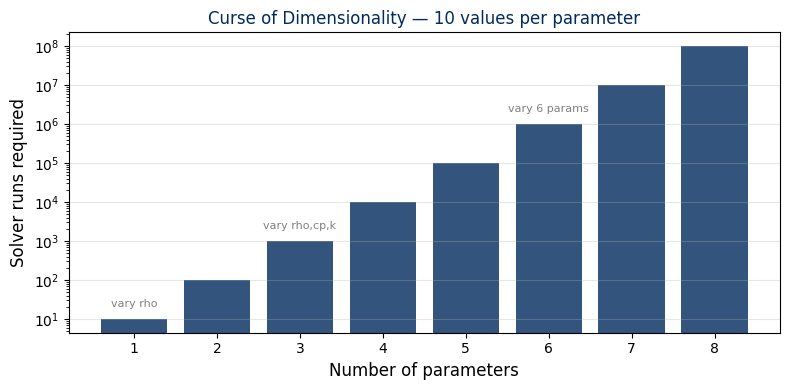

6 parameters x 10 values = 1,000,000 solver runs
At 1 min/solve: 694 days of compute


In [2]:
dims = np.arange(1, 9)
points_per_dim = 10
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dims, points_per_dim**dims, color=UP_BLUE, alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('Number of parameters', fontsize=12)
ax.set_ylabel('Solver runs required', fontsize=12)
ax.set_title('Curse of Dimensionality — 10 values per parameter',
             fontsize=12, color=UP_BLUE)
ax.set_xticks(dims)
ax.grid(True, alpha=0.3, axis='y')
for d, label in {1: 'vary rho', 3: 'vary rho,cp,k', 6: 'vary 6 params'}.items():
    ax.text(d, points_per_dim**d * 2, label, ha='center', fontsize=8, color='gray')
plt.tight_layout(); plt.show()
print(f"6 parameters x 10 values = {10**6:,} solver runs")
print(f"At 1 min/solve: {10**6/60/24:.0f} days of compute")


---
## 2. Artificial Neural Networks — Architecture

A neural network is a parametric function $f_\theta: \mathbb{R}^n \to \mathbb{R}^m$
composed of layers of simple operations.


In [3]:
display(Markdown(DEF_NEURON))

> **Definition — Neuron**  
> The fundamental computational unit of a neural network. A single neuron
> computes a weighted sum of its inputs, adds a bias, and passes the result
> through an activation function:
> $a = \sigma\!\left(\sum_j w_j x_j + b\right)$  
> Biologically inspired but mathematically a simple non-linear function.  
> *(Goodfellow et al., 2016, §6.1)*


In [4]:
display(Markdown(DEF_LAYER))

> **Definition — Layer**  
> A collection of neurons that operate in parallel on the same input.
> Each layer transforms its input vector $\mathbf{a}^{(l-1)}$ into an output
> vector $\mathbf{a}^{(l)}$ via $\mathbf{a}^{(l)} = \sigma(W^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)})$.
> Layers are stacked sequentially to form the network.  
> *(Goodfellow et al., 2016, §6.1)*


In [5]:
display(Markdown(DEF_WEIGHTS_BIAS))

> **Definition — Weights and Bias**  
> **Weights** $W^{(l)} \in \mathbb{R}^{n_l \times n_{l-1}}$ control the strength of connections
> between layers. **Bias** $\mathbf{b}^{(l)} \in \mathbb{R}^{n_l}$ shifts the activation
> threshold independently of the input. Together they are the **learnable parameters**
> $\theta$ of the network — adjusted during training to minimise the loss.  
> *(Goodfellow et al., 2016, §6.1)*


### The fully-connected layer — matrix form

$$\mathbf{z}^{(l)} = W^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}, \qquad \mathbf{a}^{(l)} = \sigma\!\left(\mathbf{z}^{(l)}\right)$$


In [6]:
display(Markdown(DEF_DEPTH_WIDTH))

> **Definition — Depth and Width**  
> **Depth** is the number of hidden layers. **Width** is the number of neurons
> per hidden layer. Depth allows the network to learn hierarchical representations
> — early layers capture simple features, deeper layers combine them into complex
> patterns. The Universal Approximation Theorem guarantees that sufficient width
> in a single hidden layer can approximate any continuous function, but depth is
> far more parameter-efficient in practice.  
> *(Goodfellow et al., 2016, §6.4)*


In [7]:
display(Markdown(DEF_FORWARD_PASS))

> **Definition — Forward Pass**  
> The sequential computation from input to output: each layer receives the
> activations of the previous layer, applies its weights, bias, and activation
> function, and passes the result forward. For a network with $L$ layers:
> $f_\theta(\mathbf{x}) = \mathbf{a}^{(L)} = \sigma^{(L)}(W^{(L)} \cdots \sigma^{(1)}(W^{(1)}\mathbf{x} + \mathbf{b}^{(1)}) \cdots + \mathbf{b}^{(L)})$  
> *(Goodfellow et al., 2016, §6.1)*


### The project network
Input: $(\hat{x}, \hat{y}, \hat{t}, \hat{\rho}, \hat{c}_p, \hat{k})$ — 6 inputs  
Architecture: 5 hidden layers × 40 neurons — **6,881 parameters**  
Output: $T$ [K]


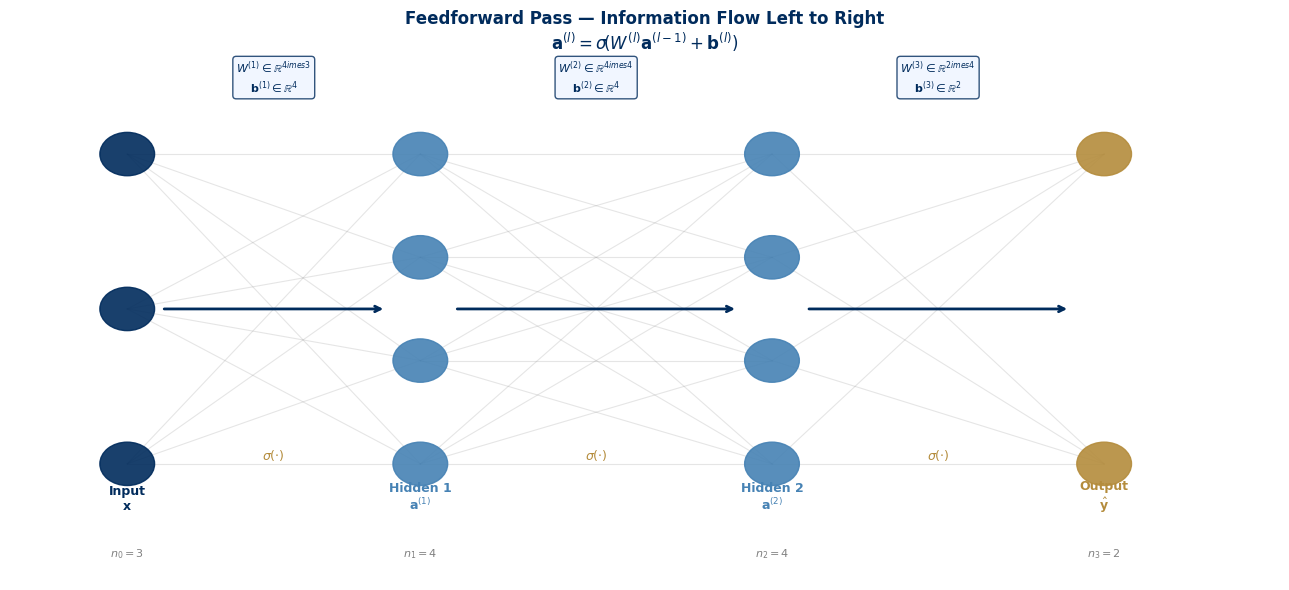

In [8]:
fig = plot_feedforward()
plt.show()


---
## 3. Activation Functions

In [9]:
display(Markdown(DEF_ACTIVATION))

> **Definition — Activation Function**  
> A non-linear function $\sigma(\cdot)$ applied element-wise to the pre-activation
> $\mathbf{z}^{(l)} = W^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$.
> Without it, any stack of linear layers collapses to a single linear transformation
> regardless of depth — the network could only represent linear functions.
> Common choices: `tanh`, `ReLU`, `sigmoid`, `ELU`.
> **For PINNs:** must be at least twice differentiable — `tanh` is the standard choice.  
> *(Goodfellow et al., 2016, §6.3)*


### The PINN constraint
PINNs compute $\partial^2 T / \partial x^2$ via autograd through the network.
The activation must be **at least twice differentiable** with **non-zero second
derivative** everywhere.

**`tanh` satisfies this. `ReLU` does not** — its second derivative is zero almost everywhere.


In [10]:
activation_explorer()

Output()

---
## 3b. Weight Initialisation — Getting the Scale Right

Initialising weights randomly seems obvious — but the *scale* of that randomness
matters critically for deep networks.

### Why not zeros?
If all weights are zero, every neuron computes identical outputs and receives
identical gradients — the network never breaks symmetry. **Random initialisation
is essential** but the scale must be chosen carefully.

### The vanishing/exploding gradient problem
For a signal passing through $L$ layers with weights drawn from $\mathcal{N}(0, \sigma^2)$:

$$\text{Var}(\mathbf{z}^{(l)}) = n_{l-1} \cdot \sigma^2 \cdot \text{Var}(\mathbf{a}^{(l-1)})$$

- $\sigma^2$ too small → variance shrinks → **vanishing signal and gradients**
- $\sigma^2$ too large → variance grows → **exploding signal and gradients**


In [11]:
display(Markdown(DEF_XAVIER))

> **Definition — Xavier / Glorot Initialisation**  
> A weight initialisation strategy that scales random weights to preserve
> signal variance across layers: $\mathrm{Var}(w) = 2/(n_{\mathrm{in}} + n_{\mathrm{out}})$.
> Prevents signals from vanishing (too small) or exploding (too large) as they
> propagate through deep networks. Essential for stable training with `tanh`.  
> *(Glorot & Bengio, 2010)*


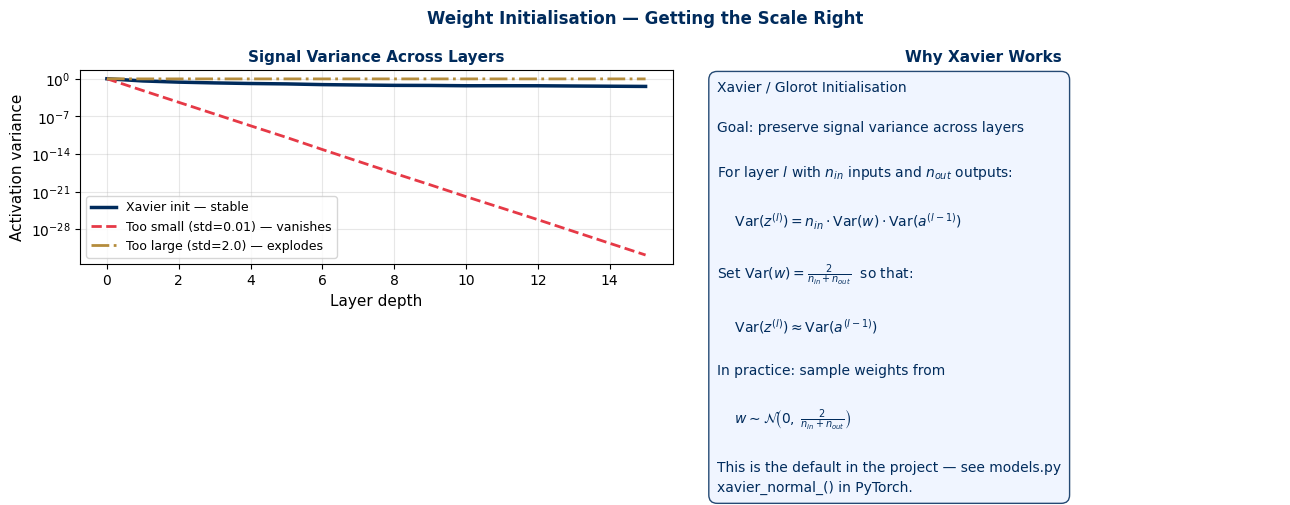

In [12]:
fig = plot_xavier_initialisation()
plt.show()


---
## 4. Training — Learning from Data

In [13]:
display(Markdown(DEF_LOSS))

> **Definition — Loss Function**  
> A scalar measure $\mathcal{L}(\theta)$ of how poorly the network predictions
> match the targets (or, for PINNs, how poorly the PDE is satisfied).
> Training minimises $\mathcal{L}$ by adjusting $\theta$.
> Common choice for regression: **Mean Squared Error (MSE)**
> $\mathcal{L} = \frac{1}{N}\sum_{i=1}^N (f_\theta(\mathbf{x}_i) - y_i)^2$.  
> *(Goodfellow et al., 2016, §6.2)*


In [14]:
display(Markdown(DEF_GRADIENT_DESCENT))

> **Definition — Gradient Descent**  
> An iterative optimisation algorithm that updates parameters in the direction
> of steepest descent of the loss:
> $\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}$
> where $\eta > 0$ is the **learning rate**. Requires differentiability of
> $\mathcal{L}$ with respect to $\theta$ — guaranteed by autograd.  
> *(Goodfellow et al., 2016, §4.3)*


In [15]:
display(Markdown(DEF_LEARNING_RATE))

> **Definition — Learning Rate** $\eta$  
> Controls the step size in gradient descent. Too large: overshoots minima,
> training diverges. Too small: converges very slowly, may get stuck.
> Adaptive methods (Adam) adjust $\eta$ per parameter automatically.  
> *(Goodfellow et al., 2016, §8.3)*


### Backpropagation — the chain rule through the network

Define the error signal at layer $l$:
$\delta^{(l)} = \partial \mathcal{L} / \partial \mathbf{z}^{(l)}$

**Output layer:** $\delta^{(L)} = \nabla_{\mathbf{a}^{(L)}} \mathcal{L} \odot \sigma'(\mathbf{z}^{(L)})$

**Hidden layers:** $\delta^{(l)} = \left(W^{(l+1)}\right)^T \delta^{(l+1)} \odot \sigma'(\mathbf{z}^{(l)})$

**Weight gradients:** $\nabla_{W^{(l)}} \mathcal{L} = \delta^{(l)} \left(\mathbf{a}^{(l-1)}\right)^T$


In [16]:
display(Markdown(DEF_BACKPROP))

> **Definition — Backpropagation**  
> An efficient algorithm for computing $\nabla_\theta \mathcal{L}$ by applying
> the chain rule backwards through the network. Defines error signals
> $\delta^{(l)} = \partial \mathcal{L} / \partial \mathbf{z}^{(l)}$ propagated
> from output to input, then uses them to compute weight gradients
> $\nabla_{W^{(l)}} \mathcal{L} = \delta^{(l)}(\mathbf{a}^{(l-1)})^T$.
> In PyTorch, `.backward()` executes this automatically via **autograd**.  
> *(Goodfellow et al., 2016, §6.5)*


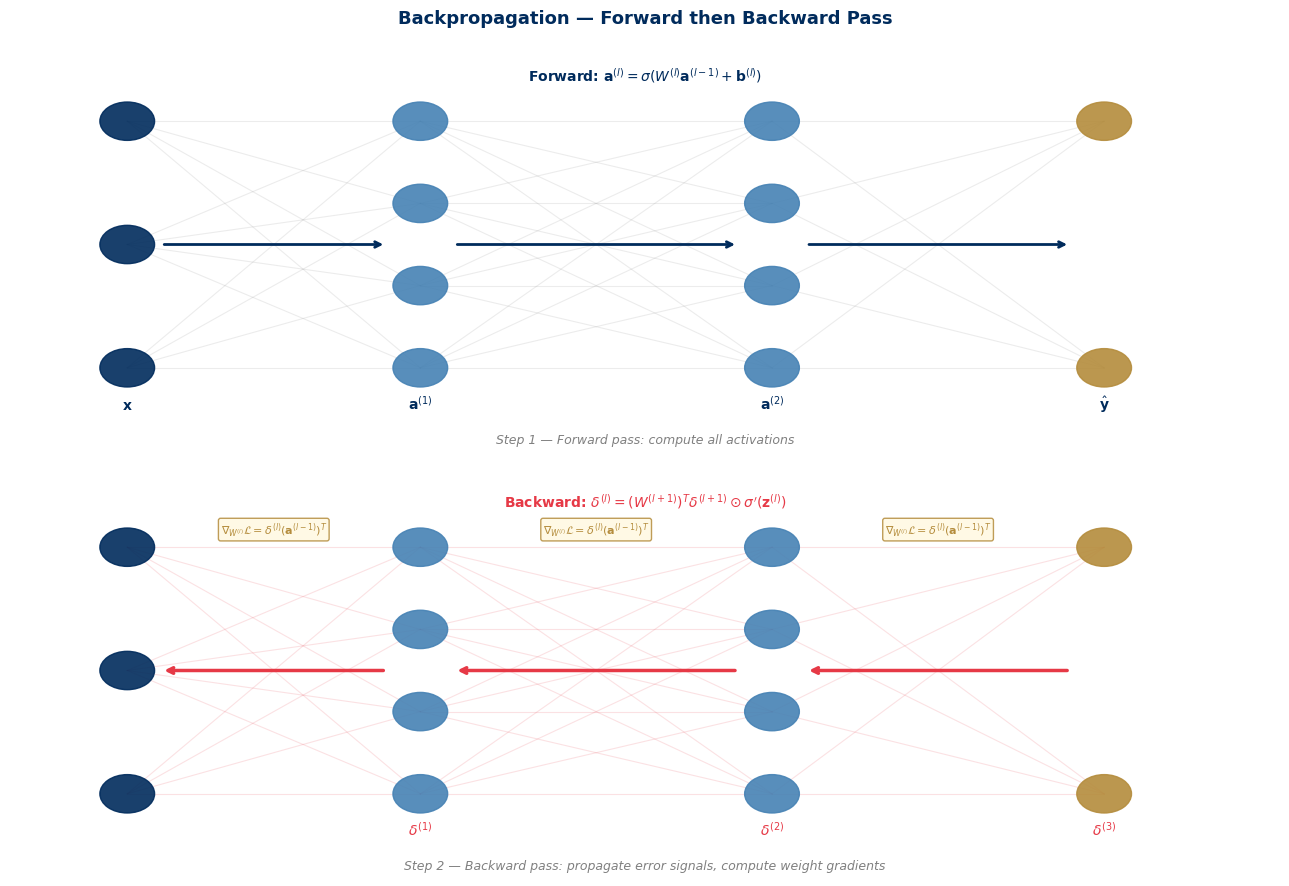

In [17]:
fig = plot_backpropagation()
plt.show()


### Adam Optimiser
$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\theta_t = \theta_{t-1} - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$


In [18]:
display(Markdown(DEF_OPTIMISER))

> **Definition — Optimiser**  
> The algorithm that uses gradients to update network parameters.
> **SGD**: fixed learning rate, noisy updates.
> **Adam** *(Kingma & Ba, 2015)*: maintains per-parameter adaptive learning rates
> using first moment $m_t$ (mean) and second moment $v_t$ (variance) of gradients:
> $\theta_t = \theta_{t-1} - \eta\,\hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon)$.
> Adam is the standard choice for PINNs.  
> *(Kingma & Ba, 2015)*


In [19]:
forward_pass_widget()

In [ ]:
loss_landscape_widget()

---
## 4b. Mini-Batch Training

In [20]:
display(Markdown(DEF_MINIBATCH))

> **Definition — Mini-batch and Epoch**  
> A **mini-batch** is a random subset of $B$ training samples used to compute
> one gradient update — a compromise between noisy single-sample (SGD) and
> expensive full-dataset updates. An **epoch** is one complete pass through the
> training dataset (i.e. $N/B$ mini-batch updates). Mini-batch training is
> standard in deep learning — it is memory-efficient, GPU-parallelisable,
> and the gradient noise helps escape local minima.  
> *(Goodfellow et al., 2016, §8.1)*


### In the project
The ANN DataLoader uses `batch_size = 512`. Each epoch shuffles all training data
and processes it in batches of 512. The PINN uses full-batch Adam on its collocation
points — since there is no data, only physics residuals.

| Method | Gradient estimate | Memory | Generalisation |
|--------|-----------------|--------|---------------|
| Full batch | Exact | High | Risk of sharp minima |
| SGD (B=1) | Very noisy | Low | Often better generalisation |
| Mini-batch | Approximate | Controlled | Best trade-off in practice |


---
## 4c. Overfitting and the Bias-Variance Trade-off

In [21]:
display(Markdown(DEF_OVERFITTING))

> **Definition — Overfitting and Underfitting**  
> **Overfitting**: the model memorises training data, including its noise,
> and fails to generalise — high training accuracy, poor test accuracy.
> **Underfitting**: the model is too simple to capture the underlying pattern
> — poor performance on both training and test data.
> Detected by monitoring a **validation set** — data held out from training
> and used only for evaluation. A growing train/val loss gap signals overfitting.  
> *(Goodfellow et al., 2016, §5.2)*


### Bias-variance decomposition
$$\mathbb{E}\left[(y - f_\theta(x))^2\right] = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\sigma^2_{\epsilon}}_{\text{irreducible noise}}$$

### How to detect overfitting
Monitor **training loss vs validation loss**:
- Both decreasing → still learning
- Train decreasing, val increasing → overfitting
- Both high → underfitting


In [22]:
display(Markdown(DEF_REGULARISATION))

> **Definition — Regularisation**  
> Techniques that reduce overfitting by constraining the model:
> - **L2 (weight decay)**: adds $\lambda\|\theta\|^2$ to the loss, penalising large weights
> - **Dropout**: randomly zeros neurons during training, preventing co-adaptation
> - **Early stopping**: halts training when validation loss begins to increase
> All three are ways of reducing effective model complexity without reducing depth or width.  
> *(Goodfellow et al., 2016, §7)*


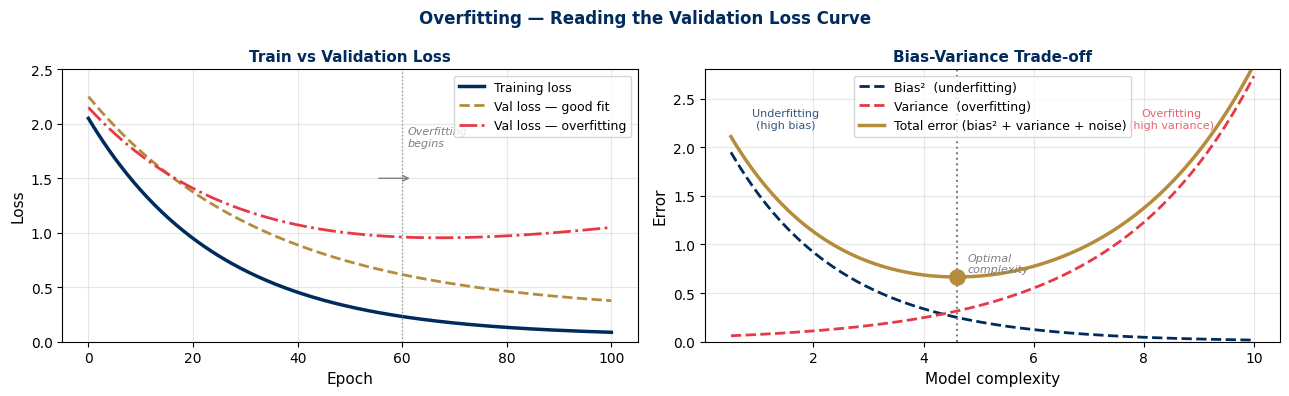

In [23]:
fig = plot_bias_variance()
plt.show()


---
## Summary — Part 1

| Concept | Key takeaway |
|---------|-------------|
| **Motivation** | Classical CFD is expensive — ML offers fast surrogates and generalisation |
| **Architecture** | Layers of matrix ops + non-linear activations — 6,881 parameters in the project |
| **Activation** | Must be twice differentiable for PINNs — use `tanh`, not `ReLU` |
| **Initialisation** | Xavier preserves signal variance — prevents vanishing/exploding gradients |
| **Backpropagation** | Chain rule through the network — same mechanism as PINN autograd |
| **Mini-batches** | Balance between noisy SGD and expensive full-batch |
| **Overfitting** | Monitor train vs val loss — stop early or regularise |

**In Part 2:** We embed the Navier-Stokes equations into the loss function,
apply this to the Von Kármán vortex street, and survey the broader SciML field.

In [24]:
display(Markdown(REFERENCES_L1))

---
## References

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.  
https://www.deeplearningbook.org  
*(Free online — the standard reference for neural network fundamentals)*

Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep
feedforward neural networks. *Proceedings of AISTATS 2010*, 249–256.  
http://proceedings.mlr.press/v9/glorot10a

Kingma, D.P., & Ba, J. (2015). Adam: A method for stochastic optimization.
*ICLR 2015*. https://arxiv.org/abs/1412.6980

Raissi, M., Perdikaris, P., & Karniadakis, G.E. (2019). Physics-informed neural
networks: A deep learning framework for solving forward and inverse problems
involving nonlinear PDEs. *Journal of Computational Physics*, 378, 686–707.  
https://doi.org/10.1016/j.jcp.2018.10.045
